# IPL 2022 Capstone Project
***The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.
These are some of the important columns that we'll focus on for meaningful insights in this project.***

Column names: Variable Type

 - date : string
 - venue : string
 - stage : string
 - team1 : string
 - team2 : string
 - toss_winner : string
 - toss_decision : string
 - first_ings_score : integer
 - second_ings_score : integer
 - match_winner : string
 - won_by : string
 - margin : integer
 - player_of_the_match : string
 - top_scorer : string
 - highscore : integer
 - best_bowling : string
 - best_bowling_fgure : string
 - gure : string

# Load All the Libaries And DataSheet


In [102]:
import numpy as np
import seaborn as sns
import pandas as pd
from matplotlib import pyplot as plt
from plotly.offline import iplot as ip

IPL = pd.read_csv(r"C:\Users\Shiva\OneDrive\Desktop\Python Lib\Practice\Seaborn\New folder\IPL.csv", low_memory=False)
plt.style.use('ggplot')

In [103]:
IPL.head(5)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


# **BASIC INFORMATION**

In [104]:
IPL.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

***We always first check how many values are null in the data***

In [105]:
IPL.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

In [106]:
print('The number of Rows in your data frame is :',IPL.shape[0],'and the number of columns are :',IPL.shape[1])


The number of Rows in your data frame is : 74 and the number of columns are : 20


***Which team Won the most matches ?***

In [107]:
Match_winners = IPL['match_winner'].value_counts()

C:\Users\Shiva\AppData\Local\Temp\ipykernel_5500\3959417659.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=Match_winners.index,x= Match_winners.values,palette='rainbow')


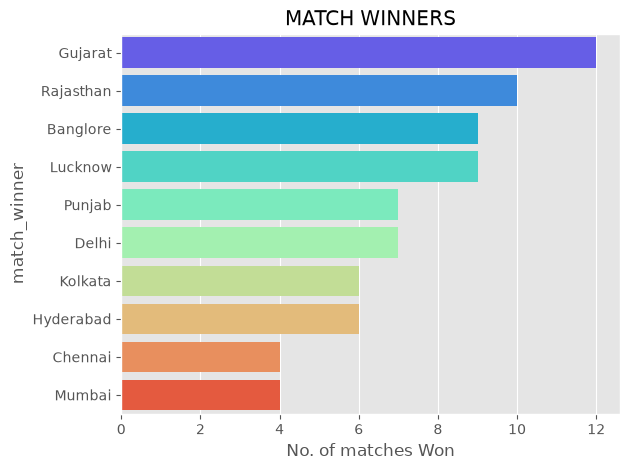

In [108]:
sns.barplot(y=Match_winners.index,x= Match_winners.values,palette='rainbow')
plt.title("MATCH WINNERS")
plt.xlabel("No. of matches Won")
plt.tight_layout()

Toss Decision Trends

In [109]:
Toss_d = IPL['toss_decision'].value_counts()
Toss_d

toss_decision
Field    59
Bat      15
Name: count, dtype: int64

C:\Users\Shiva\AppData\Local\Temp\ipykernel_5500\3729118037.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(IPL['toss_decision'],palette='coolwarm')


Text(0.5, 0, 'No. of decision')

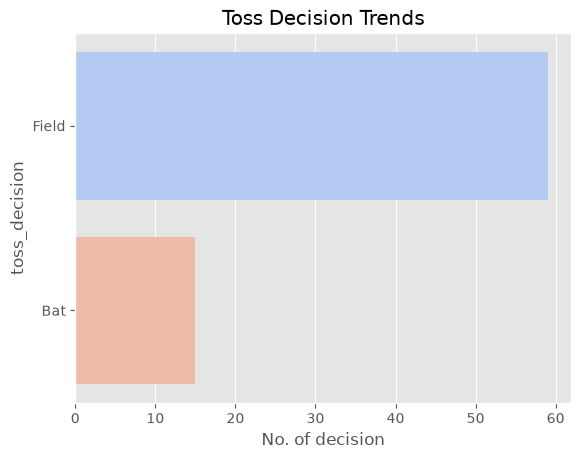

In [110]:
sns.countplot(IPL['toss_decision'],palette='coolwarm')
plt.title('Toss Decision Trends')
plt.xlabel("No. of decision")


***Toss Winner vs Match Winner***

In [111]:
count = IPL[IPL['toss_winner'] == IPL['match_winner']]['match_id'].count()
percentage = (count*100)/IPL.shape[0]
print(percentage.round(2))

48.65


***How do teams win? (Runs vs Wickets)***

C:\Users\Shiva\AppData\Local\Temp\ipykernel_5500\1576549724.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(IPL['won_by'],width= .7,palette= 'rainbow')


Text(0.5, 1.0, 'How do teams win? (Runs vs Wickets)')

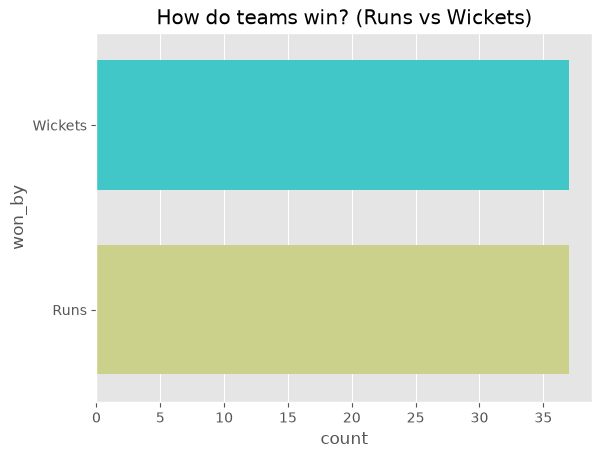

In [112]:
sns.countplot(IPL['won_by'],width= .7,palette= 'rainbow')
plt.title('How do teams win? (Runs vs Wickets)')

# Key Player Performances

1 Most "Player of the Match" Awards

In [113]:
Man = IPL['player_of_the_match'].value_counts().head(10)

C:\Users\Shiva\AppData\Local\Temp\ipykernel_5500\1514462610.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y= Man.index,x= Man.values,palette='rainbow')


Text(0.5, 1.0, 'Top 10 Man of the match')

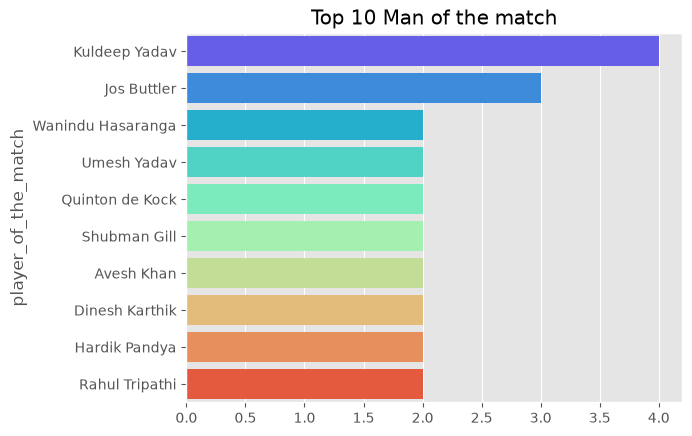

In [114]:
sns.barplot(y= Man.index,x= Man.values,palette='rainbow')
plt.title('Top 10 Man of the match')


2 Top Scorers

In [115]:
Top = IPL.groupby('top_scorer')['highscore'].sum().nlargest(2) 

C:\Users\Shiva\AppData\Local\Temp\ipykernel_5500\4240029627.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Top.values, y=Top.index,width=.6,palette='mako')


Text(0, 0.5, 'Top Scorer')

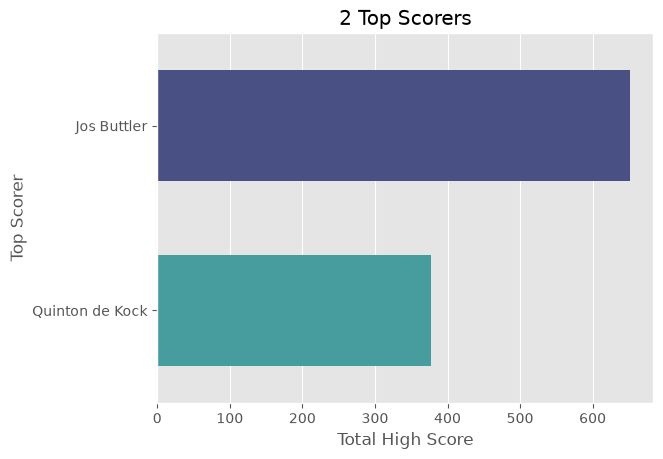

In [119]:
sns.barplot(x=Top.values, y=Top.index,width=.6,palette='mako')
plt.title('2 Top Scorers')
plt.xlabel('Total High Score')
plt.ylabel('Top Scorer')

10 Best Bowling Figures

In [155]:
IPL.head(6)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,Wicket,highest_wickets
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,...,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20,3,3
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,...,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18,3,3
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,...,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59,2,2
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,...,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25,3,3
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,...,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22,3,3
5,6,"March 30,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Kolkata,Group,Banglore,Field,128,10,...,Banglore,Wickets,3,Wanindu Hasaranga,Sherfane Rutherford,28,Wanindu Hasaranga,4--20,4,4


<Axes: ylabel='best_bowling'>

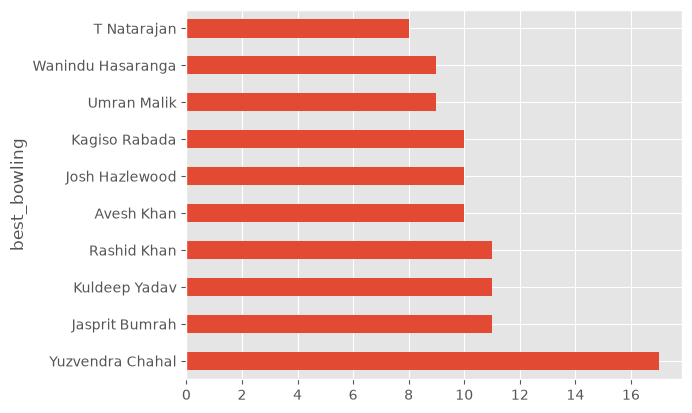

In [192]:
IPL['highest_wickets'] = IPL['best_bowling_figure'].apply(lambda x :x.split('--')[0])
IPL['highest_wickets'] = IPL['highest_wickets'].astype(int)
top_bowlers = IPL.groupby('best_bowling')['highest_wickets'].sum().nlargest(10)
top_bowlers.plot(kind = 'barh')

# Venue Analysis

Most Matches Played by Venue

In [140]:
IPL['venue'].value_counts().nlargest(10)

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

C:\Users\Shiva\AppData\Local\Temp\ipykernel_5500\701474920.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(IPL['venue'],palette='rainbow')


<Axes: xlabel='count', ylabel='venue'>

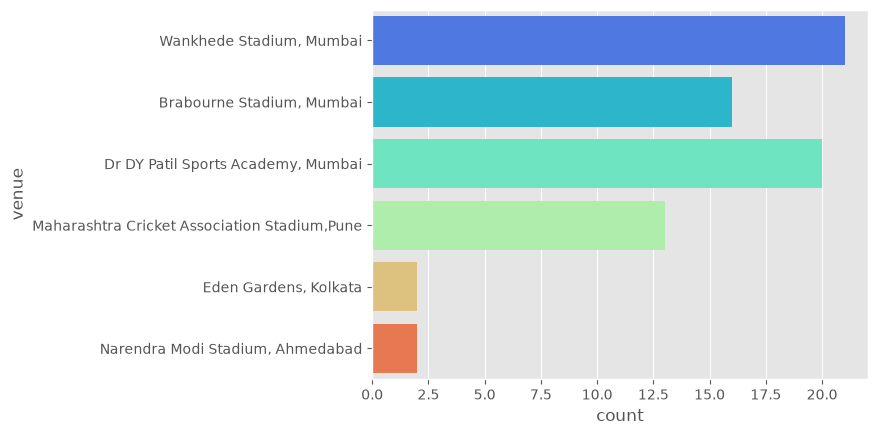

In [145]:
sns.countplot(IPL['venue'],palette='rainbow')

# Custom Questions & Insights

Q1: Who won the highest margin by runs?

In [175]:
IPL.head(5)
T = IPL[IPL['won_by']  == 'Runs'].sort_values(by= 'margin',ascending=False)[['match_winner','margin']].head(5)
T

,match_winner,margin
54,Chennai,91
52,Lucknow,75
53,Banglore,67
56,Gujarat,62
4,Rajasthan,61


Q2: Which player had the highest individual score?

In [185]:
IPL[IPL['highscore'] == IPL['highscore'].max()][['top_scorer','highscore']]


,top_scorer,highscore
65,Quinton de Kock,140


Q3: Which bowler had the best bowling figures?

In [190]:
IPL[IPL['highest_wickets'] == IPL['highest_wickets'].max()][['best_bowling','best_bowling_figure']]

,best_bowling,best_bowling_figure
29,Yuzvendra Chahal,5--40
39,Umran Malik,5--25
53,Wanindu Hasaranga,5--18
55,Jasprit Bumrah,5--10
